In [2]:
!pip install fastai
import pandas as pd
from fastai.vision.all import *


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 86.9 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.

In [19]:
df = pd.read_csv('/kaggle/input/datasets/nour12347653/skin-disease-detection-dataset-ham10000-isic/HAM10000_metadata.csv')
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [23]:
df['image_id'] = df['image_id'].astype(str) + '.jpg'
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419.jpg,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030.jpg,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769.jpg,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661.jpg,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633.jpg,bkl,histo,75.0,male,ear


selecting 90% of datas to be used for building the skin disease classification model, as the rest 10% of datas will be used for testing.

In [24]:
df_to_be_used =df.iloc[:9013]
df_to_be_used.shape

(9013, 7)

In [25]:
path = Path('/kaggle/input/datasets/nour12347653/skin-disease-detection-dataset-ham10000-isic/processed_images_dataset/processed_images')

datablock = DataBlock(blocks=(ImageBlock, CategoryBlock),
                   splitter=RandomSplitter(valid_pct = 0.2 , seed = 42),  #splitting the datas into train and test 
                   get_x=ColReader('image_id',pref=path),   #the source of the data is the path to the image, and we are using the path as the prefix to each filepaths
                   get_y=ColReader('dx'),    #labels to identify the category of the image
                   item_tfms = [Resize(192, method = 'squish')],
                   )


Loading the data with the help of datablock

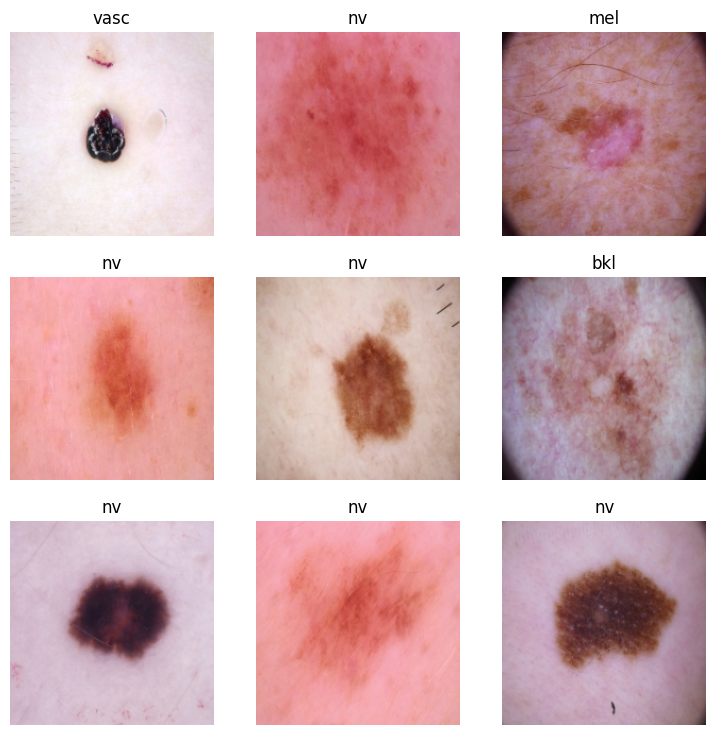

In [26]:
dls = datablock.dataloaders(df_to_be_used)
dls.show_batch()

Fine tuning the vision learner model

In [28]:
learn = vision_learner(dls,resnet18,metrics= error_rate)
learn.fine_tune(6)

epoch,train_loss,valid_loss,error_rate,time
0,1.585353,0.956420,0.279689,00:18


epoch,train_loss,valid_loss,error_rate,time
0,0.862706,0.740264,0.235849,00:22
1,0.535234,0.677799,0.203108,00:21
2,0.283376,0.653359,0.181465,00:21
3,0.116938,0.675183,0.174251,00:21
4,0.055356,0.727430,0.172031,00:21
5,0.033398,0.748738,0.172586,00:21


from the above report, we can observe that upto epoch 3, both the training as well as validation lsos is decreasing but after this , the validation loss is increasing even though the training loss is decreasing, showing the sign of overfitting.

In [30]:
learn = vision_learner(dls,resnet18,metrics= error_rate)
learn.fine_tune(4)

epoch,train_loss,valid_loss,error_rate,time
0,1.559314,0.984901,0.285794,00:15


epoch,train_loss,valid_loss,error_rate,time
0,0.839816,0.761918,0.238069,00:21
1,0.544705,0.634849,0.195893,00:20
2,0.251997,0.628859,0.184240,00:20
3,0.110190,0.625345,0.178690,00:20


Prediction done by our model on test dataset, as until the row 9013, we were using the datas as training and validation dataset. So, from the row 9014, all the datas are test dataset.

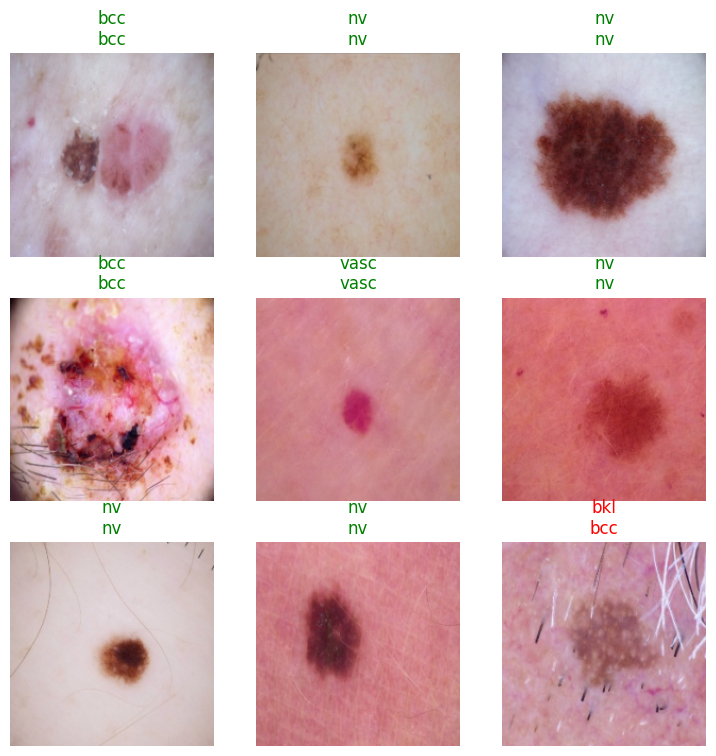

In [33]:
learn.predict(str(path) + '/' +  df.iloc[9014]['image_id'])
learn.show_results()